In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="Blues")

In [4]:
bike = pd.read_csv("citibike_2022_full.csv")
weather = pd.read_csv("lga_weather_2022.csv")



/var/folders/r7/hpnbv35s3194ffb_bhsw50nc0000gn/T/ipykernel_2902/2713746911.py:1: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  bike = pd.read_csv("citibike_2022_full.csv")


Bike shape: (1163216, 13)
Weather shape: (365, 5)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,3A2034DA67C8874B,electric_bike,2022-09-14 20:37:39.155,2022-09-14 21:05:39.760,N 12 St & Bedford Ave,5450.04,Albany St & Greenwich St,5145.02,40.720796,-73.954882,40.709267,-74.013247,casual
1,F1C63DACDCC1C33D,electric_bike,2022-09-17 19:21:39.407,2022-09-17 20:08:32.670,Union Ave & Jackson St,5300.06,Metropolitan Ave & Meeker Ave,5300.05,40.716075,-73.952029,40.714133,-73.952344,casual
2,94372C52777F4AC1,electric_bike,2022-09-17 16:49:21.830,2022-09-17 17:01:51.537,S 4 St & Wythe Ave,5204.05,St Marks Pl & 1 Ave,5626.13,40.712874,-73.965935,40.727791,-73.985649,casual
3,44818FEC94B62B66,electric_bike,2022-09-08 12:27:40.019,2022-09-08 12:47:15.649,Amsterdam Ave & W 73 St,7260.09,Washington St & Gansevoort St,6039.06,40.779668,-73.980930,40.739323,-74.008119,casual
4,F8A63709F214EBAA,classic_bike,2022-09-16 19:00:19.266,2022-09-16 19:07:28.905,University Pl & E 14 St,5905.14,Washington St & Gansevoort St,6039.06,40.734814,-73.992085,40.739323,-74.008119,member


In [11]:
top_20_stations = (
    bike["start_station_name"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_20_stations.columns = ["start_station", "ride_count"]
top_20_stations

,start_station,ride_count
0,West St & Chambers St,5604
1,West St & Liberty St,4615
2,Broadway & W 58 St,4389
3,6 Ave & W 33 St,4298
4,Lafayette St & E 8 St,4292
5,W 21 St & 6 Ave,4243
6,E 10 St & Avenue A,3916
7,1 Ave & E 68 St,3886
8,W 22 St & 10 Ave,3846
9,Central Park S & 6 Ave,3793


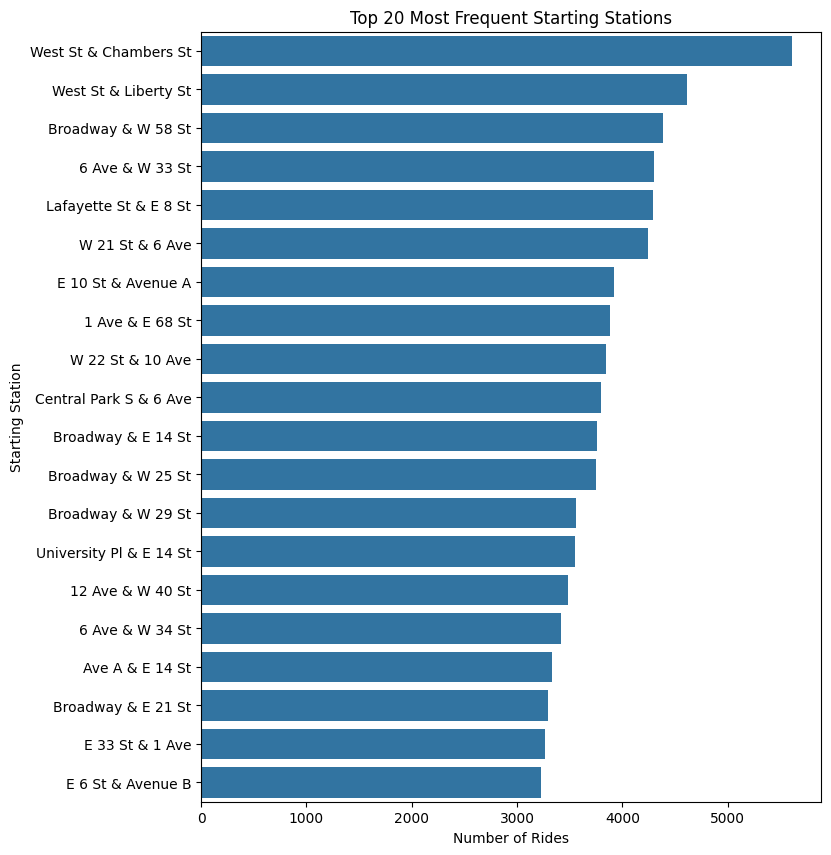

In [12]:
plt.figure(figsize=(8, 10))
sns.barplot(
    data=top_20_stations,
    x="ride_count",
    y="start_station"
)

plt.title("Top 20 Most Frequent Starting Stations")
plt.xlabel("Number of Rides")
plt.ylabel("Starting Station")
plt.show()

/var/folders/r7/hpnbv35s3194ffb_bhsw50nc0000gn/T/ipykernel_2902/4098048996.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


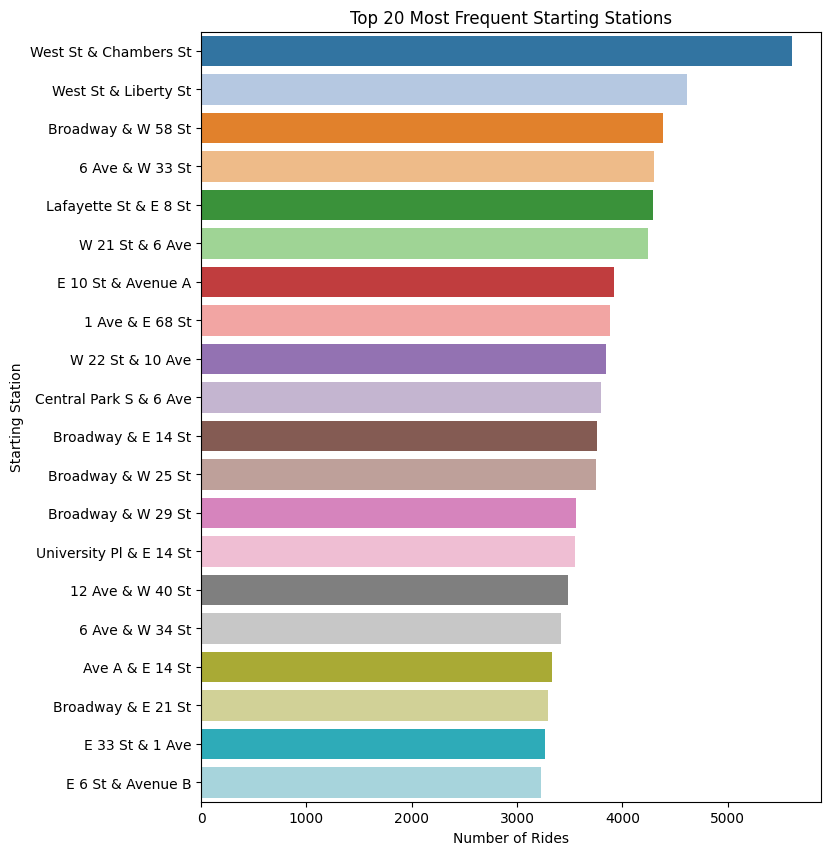

In [13]:
plt.figure(figsize=(8, 10))
sns.barplot(
    data=top_20_stations,
    x="ride_count",
    y="start_station",
    palette="tab20"
)

plt.title("Top 20 Most Frequent Starting Stations")
plt.xlabel("Number of Rides")
plt.ylabel("Starting Station")
plt.show()

The original Blues palette did not provide enough distinct colors for a bar chart with 20 categories, making it difficult to differentiate between stations. After changing the palette for this plot to tab20, each bar became visually distinct, improving clarity and interpretability while keeping the overall visualization style consistent across the notebook.

In [14]:

bike["started_at"] = pd.to_datetime(bike["started_at"])

# extract month
bike["month"] = bike["started_at"].dt.to_period("M").astype(str)

# create avg_temp from weather
weather["avg_temp"] = (weather["TMAX"] + weather["TMIN"]) / 2

# prepare monthly rides
monthly_rides = (
    bike.groupby("month")
    .size()
    .reset_index(name="rides")
)

# prepare monthly temperature
weather["month"] = pd.to_datetime(weather["date"]).dt.to_period("M").astype(str)

monthly_temp = (
    weather.groupby("month")["avg_temp"]
    .mean()
    .reset_index()
)

# merge for plotting
monthly = monthly_rides.merge(monthly_temp, on="month")
monthly.head()

,month,rides,avg_temp
0,2022-04,2,11.321667
1,2022-05,3,17.895161
2,2022-06,1,22.368333
3,2022-07,2,27.262903
4,2022-08,355,27.095161


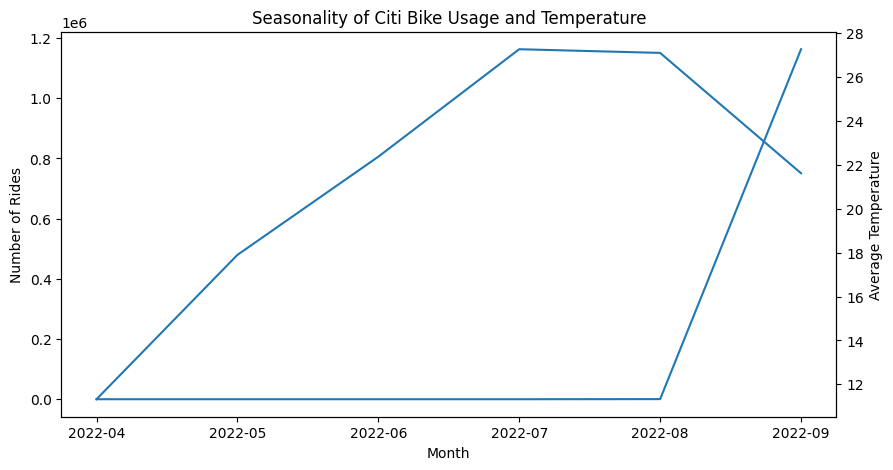

In [15]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# rides (left axis)
sns.lineplot(
    data=monthly,
    x="month",
    y="rides",
    ax=ax1
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Number of Rides")

# temperature (right axis)
ax2 = ax1.twinx()
sns.lineplot(
    data=monthly,
    x="month",
    y="avg_temp",
    ax=ax2
)
ax2.set_ylabel("Average Temperature")

plt.title("Seasonality of Citi Bike Usage and Temperature")
plt.xticks(rotation=45)
plt.show()

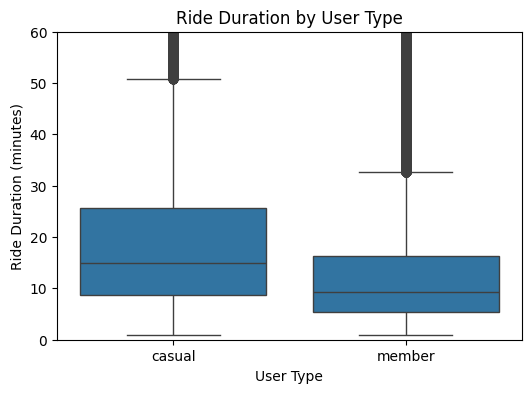

In [16]:

bike["started_at"] = pd.to_datetime(bike["started_at"])
bike["ended_at"] = pd.to_datetime(bike["ended_at"])

# calculate ride duration in minutes
bike["ride_duration_min"] = (
    (bike["ended_at"] - bike["started_at"]).dt.total_seconds() / 60
)

# box plot
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=bike,
    x="member_casual",
    y="ride_duration_min"
)

plt.title("Ride Duration by User Type")
plt.xlabel("User Type")
plt.ylabel("Ride Duration (minutes)")
plt.ylim(0, 60)
plt.show()

The box plot shows that casual riders have a higher median ride duration and greater variability compared to members. Member rides are shorter and more consistent, indicating routine usage patterns. The outliers among casual riders suggest occasional long, recreational trips.


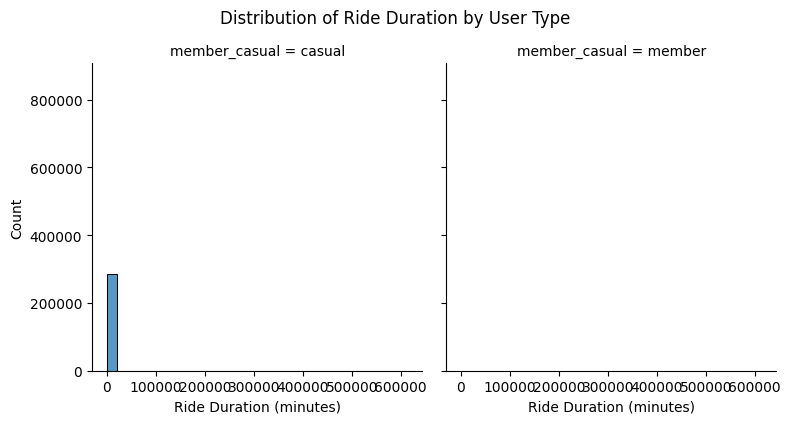

In [17]:
g = sns.FacetGrid(
    bike,
    col="member_casual",
    height=4,
    aspect=1
)

g.map(sns.histplot, "ride_duration_min", bins=30)
g.set_axis_labels("Ride Duration (minutes)", "Count")
g.fig.suptitle("Distribution of Ride Duration by User Type", y=1.05)

plt.show()

The FacetGrid shows that ride durations for both casual and member users are right-skewed, with most rides lasting a short amount of time. Casual riders display a wider spread of ride durations and more longer rides, suggesting more recreational usage. In contrast, member rides are more concentrated at shorter durations, indicating more consistent and utilitarian travel patterns.